# Flight Operations Analysis & Prediction

## Main target of this:

This project analyses flight operations data to identify patterns associated with delays and investigates whether flight delays can be predicted using machine learning.

### Questions to focus on:

- How frequently are flights delayed?
- Which airlines and airports have the highest delay rates?
- Does departure time affect delays?
- Is there a relationship between departure and arrival delays?
- Can we predict whether a flight will be delayed?


This project looks at flight delays in January 2025 and I will explore whether flight information can be used to predict delays or not.

## Loading the Data

Firstly, I loaded the flight dataset and checked its size and columns with the use of the pandas module.

In [62]:
import pandas as pd

In [63]:
df = pd.read_csv("../data/flights.csv")

In [64]:
df.head()

,FL_DATE,OP_UNIQUE_CARRIER,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,ARR_TIME,ARR_DELAY,CANCELLED,DISTANCE
0,1/1/2025 12:00:00 AM,AA,ABQ,DFW,500,452.0,-8.0,733.0,-21.0,0.0,569.0
1,1/1/2025 12:00:00 AM,AA,ABQ,DFW,555,552.0,-3.0,832.0,-17.0,0.0,569.0
2,1/1/2025 12:00:00 AM,AA,ABQ,DFW,820,815.0,-5.0,1052.0,-22.0,0.0,569.0
3,1/1/2025 12:00:00 AM,AA,ABQ,DFW,1032,1029.0,-3.0,1300.0,-23.0,0.0,569.0
4,1/1/2025 12:00:00 AM,AA,ABQ,DFW,1700,1707.0,7.0,2005.0,17.0,0.0,569.0


In [65]:
df.shape

(539747, 11)

In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 539747 entries, 0 to 539746
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   FL_DATE            539747 non-null  str    
 1   OP_UNIQUE_CARRIER  539747 non-null  str    
 2   ORIGIN             539747 non-null  str    
 3   DEST               539747 non-null  str    
 4   CRS_DEP_TIME       539747 non-null  int64  
 5   DEP_TIME           523861 non-null  float64
 6   DEP_DELAY          523824 non-null  float64
 7   ARR_TIME           523167 non-null  float64
 8   ARR_DELAY          522269 non-null  float64
 9   CANCELLED          539747 non-null  float64
 10  DISTANCE           539747 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 45.3 MB


## Checking the Data

I checked for missing values to see which columns needed attention before analysing the flights.


In [67]:
df.isnull().sum()

FL_DATE                  0
OP_UNIQUE_CARRIER        0
ORIGIN                   0
DEST                     0
CRS_DEP_TIME             0
DEP_TIME             15886
DEP_DELAY            15923
ARR_TIME             16580
ARR_DELAY            17478
CANCELLED                0
DISTANCE                 0
dtype: int64

In [68]:
df["CANCELLED"].value_counts()

CANCELLED
0.0    523435
1.0     16312
Name: count, dtype: int64

In [69]:
df[df["CANCELLED"] == 1][
    ["DEP_TIME", "DEP_DELAY", "ARR_TIME", "ARR_DELAY"]
].head()

,DEP_TIME,DEP_DELAY,ARR_TIME,ARR_DELAY
1703,NaN,NaN,NaN,NaN
2470,NaN,NaN,NaN,NaN
2642,650.0,-10.0,NaN,NaN
2925,1946.0,-11.0,NaN,NaN
3583,NaN,NaN,NaN,NaN


## Cleaning the Data

THe cancelled flights did not have a normal departure and arrival time, so I removed them before analysing delays to ensure no anomalies.


In [70]:
operated_flights = df[df["CANCELLED"] == 0].copy()

In [71]:
operated_flights.shape

(523435, 11)

In [72]:
operated_flights["DEP_DELAY"].isnull().sum()

np.int64(0)

## Creating a Delay Variable

I defined a flight as delayed when its departure delay was more than 15 minutes. This is so that it gives me a target variable that the machine learning model will try to predict.


In [73]:
operated_flights["Delayed"] = (
    operated_flights["DEP_DELAY"] > 15
).astype(int)

In [74]:
operated_flights["Delayed"].value_counts()

Delayed
0    431245
1     92190
Name: count, dtype: int64

In [75]:
operated_flights["Delayed"].mean() * 100

np.float64(17.61250202986044)

## Looking into Flight Delays

Before building a prediction model, I wanted to understand the data and to research where delays were more common.


<Axes: title={'center': 'Flight Delays in January 2025'}, xlabel='Delayed by more than 15 minutes', ylabel='Number of flights'>

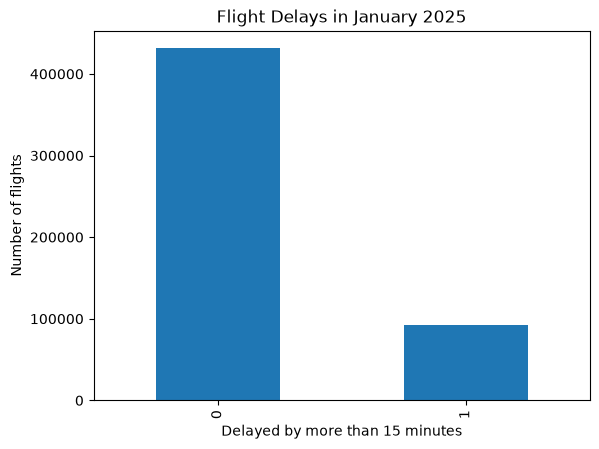

In [76]:
delay_counts = operated_flights["Delayed"].value_counts()

delay_counts.plot(
    kind="bar",
    title="Flight Delays in January 2025",
    xlabel="Delayed by more than 15 minutes",
    ylabel="Number of flights"
)

<Axes: title={'center': 'Flight Delays in January 2025'}, xlabel='Departure delay', ylabel='Number of flights'>

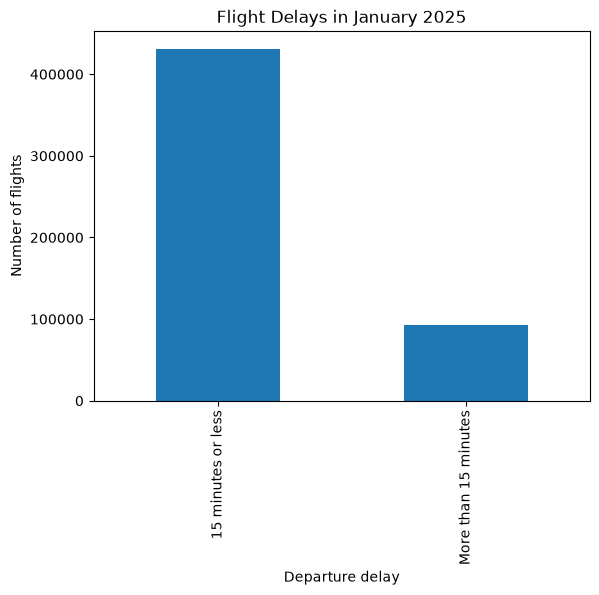

In [77]:
delay_counts.index = ["15 minutes or less", "More than 15 minutes"]

delay_counts.plot(
    kind="bar",
    title="Flight Delays in January 2025",
    xlabel="Departure delay",
    ylabel="Number of flights"
)

## Delays by Airline

I compared the delay rate between airlines to see whether some airlines had a higher amount of delayed flights.


In [78]:
airline_delay_rate = (
    operated_flights
    .groupby("OP_UNIQUE_CARRIER")["Delayed"]
    .mean()
    * 100
)

In [79]:
airline_delay_rate

OP_UNIQUE_CARRIER
AA    18.186094
AS    16.004464
B6    21.818698
DL    18.937831
F9    22.538655
G4    22.848472
HA    10.972265
MQ    15.239693
NK    17.464058
OH    22.573587
OO    18.242193
UA    16.036371
WN    16.671066
YX    11.795313
Name: Delayed, dtype: float64

In [80]:
operated_flights["OP_UNIQUE_CARRIER"].unique()

<StringArray>
['AA', 'AS', 'B6', 'DL', 'F9', 'G4', 'HA', 'MQ', 'NK', 'OH', 'OO', 'UA', 'WN',
 'YX']
Length: 14, dtype: str

In [81]:
df["OP_UNIQUE_CARRIER"].value_counts()

OP_UNIQUE_CARRIER
WN    105307
DL     76306
AA     75088
OO     65036
UA     62007
YX     27833
MQ     21890
OH     21094
AS     18163
B6     17918
NK     17544
F9     15526
G4      9345
HA      6690
Name: count, dtype: int64

In [82]:
airline_names = {
    "AA": "American Airlines",
    "AS": "Alaska Airlines",
    "B6": "JetBlue",
    "DL": "Delta",
    "F9": "Frontier",
    "G4": "Allegiant",
    "HA": "Hawaiian Airlines",
    "MQ": "Envoy Air",
    "NK": "Spirit",
    "OH": "PSA Airlines",
    "OO": "SkyWest",
    "UA": "United",
    "WN": "Southwest",
    "YX": "Republic Airways"
}

In [83]:
operated_flights["Airline"] = operated_flights["OP_UNIQUE_CARRIER"].map(airline_names)

In [84]:
operated_flights[["OP_UNIQUE_CARRIER", "Airline"]].drop_duplicates()

,OP_UNIQUE_CARRIER,Airline
0,AA,American Airlines
2408,AS,Alaska Airlines
3035,B6,JetBlue
3735,DL,Delta
5838,F9,Frontier
6410,G4,Allegiant
6668,HA,Hawaiian Airlines
6859,MQ,Envoy Air
7568,NK,Spirit
8159,OH,PSA Airlines


In [85]:
airline_delay_rate_named = airline_delay_rate.rename(index=airline_names)

In [86]:
airline_delay_rate_named = airline_delay_rate_named.sort_values(ascending=False)

In [87]:
airline_delay_rate_named

OP_UNIQUE_CARRIER
Allegiant            22.848472
PSA Airlines         22.573587
Frontier             22.538655
JetBlue              21.818698
Delta                18.937831
SkyWest              18.242193
American Airlines    18.186094
Spirit               17.464058
Southwest            16.671066
United               16.036371
Alaska Airlines      16.004464
Envoy Air            15.239693
Republic Airways     11.795313
Hawaiian Airlines    10.972265
Name: Delayed, dtype: float64

<Axes: title={'center': 'Flight Delay Rate by Airline - January 2025'}, xlabel='Airline', ylabel='Flights delayed by more than 15 minutes (%)'>

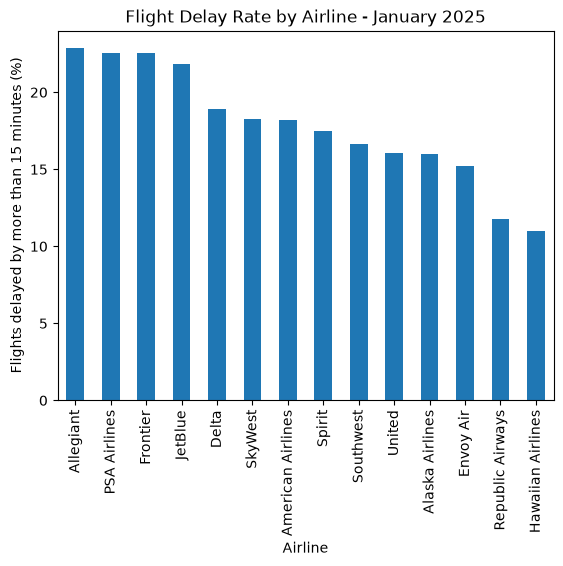

In [88]:
airline_delay_rate_named.plot(
    kind="bar",
    title="Flight Delay Rate by Airline - January 2025",
    xlabel="Airline",
    ylabel="Flights delayed by more than 15 minutes (%)"
)

In [89]:
airline_summary = operated_flights.groupby("Airline").agg(
    flights=("Delayed", "count"),
    delayed_flights=("Delayed", "sum"),
    delay_rate=("Delayed", "mean")
)

In [90]:
airline_summary["delay_rate"] = airline_summary["delay_rate"] * 100

In [91]:
airline_summary.sort_values("delay_rate", ascending=False)

,flights,delayed_flights,delay_rate
Airline,,,
Allegiant,9226,2108,22.848472
PSA Airlines,19195,4333,22.573587
Frontier,15134,3411,22.538655
JetBlue,17595,3839,21.818698
Delta,74169,14046,18.937831
SkyWest,63693,11619,18.242193
American Airlines,72286,13146,18.186094
Spirit,16972,2964,17.464058
Southwest,102291,17053,16.671066


In [92]:
operated_flights["ORIGIN"].nunique()

329

In [93]:
airport_counts = operated_flights["ORIGIN"].value_counts()
airport_counts.head(10)

ORIGIN
DEN    24419
DFW    23532
ATL    22633
ORD    21260
CLT    16117
PHX    15807
LAX    14999
LAS    14839
MCO    12847
SEA    11773
Name: count, dtype: int64

## Delays by Departure Airport

In addition to this, I also compared airports to see which departure airports had the highest delay rates. 


In [94]:
airport_delay_rate = (
    operated_flights
    .groupby("ORIGIN")["Delayed"]
    .mean()
    * 100
)

In [95]:
airport_summary = operated_flights.groupby("ORIGIN").agg(
    flights=("Delayed", "count"),
    delayed_flights=("Delayed", "sum"),
    delay_rate=("Delayed", "mean")
)

In [96]:
airport_summary["delay_rate"] = airport_summary["delay_rate"] * 100

In [97]:
airport_summary = airport_summary[
    airport_summary["flights"] >= 1000
]

In [98]:
airport_summary.sort_values(
    "delay_rate",
    ascending=False
).head(10)

,flights,delayed_flights,delay_rate
ORIGIN,,,
PBI,2889,755,26.133610
SJU,3159,789,24.976258
FLL,7716,1837,23.807672
DFW,23532,5346,22.718001
DEN,24419,5505,22.543921
ATL,22633,4899,21.645385
IAH,8732,1885,21.587265
MIA,9966,2135,21.422838
MCO,12847,2619,20.386082


<Axes: title={'center': 'Top 10 Airport Delay Rates - January 2025'}, xlabel='Departure delay rate (%)', ylabel='Airport'>

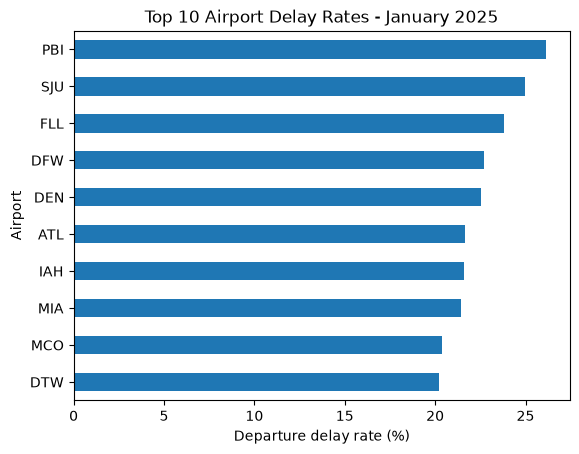

In [99]:
top_airports = airport_summary.sort_values(
    "delay_rate",
    ascending=False
).head(10)

top_airports["delay_rate"].sort_values().plot(
    kind="barh",
    title="Top 10 Airport Delay Rates - January 2025",
    xlabel="Departure delay rate (%)",
    ylabel="Airport"
)

## Delays by Scheduled Departure Time

I looked at the scheduled departure hour to see whether the time of day was related to flight delays.


In [100]:
operated_flights["Scheduled_Hour"] = (
    operated_flights["CRS_DEP_TIME"] // 100
)

In [101]:
operated_flights[
    ["CRS_DEP_TIME", "Scheduled_Hour"]
].head(10)

,CRS_DEP_TIME,Scheduled_Hour
0,500,5
1,555,5
2,820,8
3,1032,10
4,1700,17
5,1343,13
6,510,5
7,1134,11
8,1611,16
9,537,5


In [102]:
hourly_delay_rate = (
    operated_flights
    .groupby("Scheduled_Hour")["Delayed"]
    .mean()
    * 100
)

In [103]:
hourly_delay_rate

Scheduled_Hour
0     14.716312
1     18.085106
2     23.655914
3     18.181818
4     32.000000
5      8.591423
6      7.793017
7      9.696325
8     11.406320
9     13.893752
10    16.282833
11    17.464587
12    18.879396
13    19.484591
14    20.860647
15    21.373724
16    21.534933
17    21.621781
18    22.378375
19    23.448092
20    24.155496
21    23.679021
22    21.983693
23    15.989011
Name: Delayed, dtype: float64

<Axes: title={'center': 'Departure Delay Rate by Scheduled Departure Hour'}, xlabel='Scheduled departure hour', ylabel='Flights delayed by more than 15 minutes (%)'>

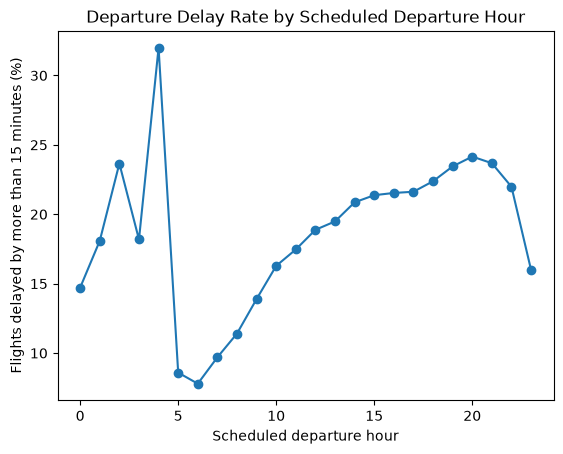

In [104]:
hourly_delay_rate.plot(
    kind="line",
    marker="o",
    title="Departure Delay Rate by Scheduled Departure Hour",
    xlabel="Scheduled departure hour",
    ylabel="Flights delayed by more than 15 minutes (%)"
)

In [105]:
hourly_flight_count = operated_flights["Scheduled_Hour"].value_counts().sort_index()
hourly_flight_count

Scheduled_Hour
0       564
1       282
2        93
3        55
4        25
5     13432
6     35288
7     36684
8     37751
9     31417
10    32132
11    34945
12    32072
13    31897
14    31883
15    30865
16    30959
17    33901
18    32518
19    26258
20    22380
21    14705
22     9689
23     3640
Name: count, dtype: int64

In [106]:
hourly_summary = operated_flights.groupby("Scheduled_Hour").agg(
    flights=("Delayed", "count"),
    delayed_flights=("Delayed", "sum"),
    delay_rate=("Delayed", "mean")
)

hourly_summary["delay_rate"] = hourly_summary["delay_rate"] * 100

hourly_summary

,flights,delayed_flights,delay_rate
Scheduled_Hour,,,
0,564,83,14.716312
1,282,51,18.085106
2,93,22,23.655914
3,55,10,18.181818
4,25,8,32.000000
5,13432,1154,8.591423
6,35288,2750,7.793017
7,36684,3557,9.696325
8,37751,4306,11.406320


<Axes: title={'center': 'Departure Delay Rate by Scheduled Departure Hour'}, xlabel='Scheduled departure hour', ylabel='Flights delayed by more than 15 minutes (%)'>

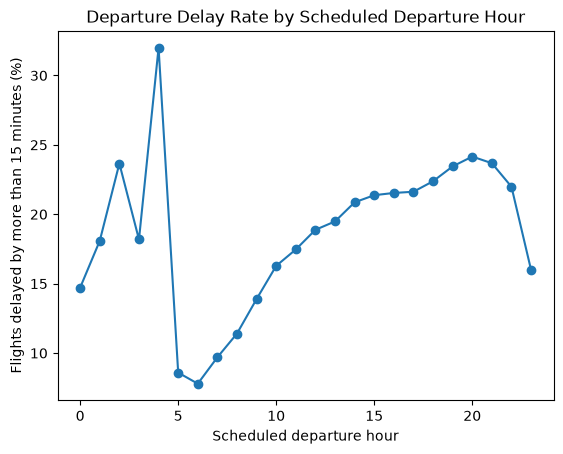

In [107]:
hourly_delay_rate.plot(
    kind="line",
    marker="o",
    title="Departure Delay Rate by Scheduled Departure Hour",
    xlabel="Scheduled departure hour",
    ylabel="Flights delayed by more than 15 minutes (%)"
)

## Preparing Data for machine learning

I selected information that would be available before the flight departed. I did not use actual departure or arrival delays because those would not be known when making a prediction.


In [108]:
model_data = operated_flights[
    [
        "OP_UNIQUE_CARRIER",
        "ORIGIN",
        "DEST",
        "CRS_DEP_TIME",
        "DISTANCE",
        "Delayed"
    ]
].copy()

In [109]:
model_data.head()

,OP_UNIQUE_CARRIER,ORIGIN,DEST,CRS_DEP_TIME,DISTANCE,Delayed
0,AA,ABQ,DFW,500,569.0,0
1,AA,ABQ,DFW,555,569.0,0
2,AA,ABQ,DFW,820,569.0,0
3,AA,ABQ,DFW,1032,569.0,0
4,AA,ABQ,DFW,1700,569.0,0


In [110]:
model_data.shape

(523435, 6)

In [111]:
model_data = operated_flights[
    [
        "OP_UNIQUE_CARRIER",
        "ORIGIN",
        "DEST",
        "Scheduled_Hour",
        "DISTANCE",
        "Delayed"
    ]
].copy()

In [112]:
model_data.head()

,OP_UNIQUE_CARRIER,ORIGIN,DEST,Scheduled_Hour,DISTANCE,Delayed
0,AA,ABQ,DFW,5,569.0,0
1,AA,ABQ,DFW,5,569.0,0
2,AA,ABQ,DFW,8,569.0,0
3,AA,ABQ,DFW,10,569.0,0
4,AA,ABQ,DFW,17,569.0,0


In [113]:
X = model_data.drop("Delayed", axis=1)
y = model_data["Delayed"]

In [114]:
X.head()

,OP_UNIQUE_CARRIER,ORIGIN,DEST,Scheduled_Hour,DISTANCE
0,AA,ABQ,DFW,5,569.0
1,AA,ABQ,DFW,5,569.0
2,AA,ABQ,DFW,8,569.0
3,AA,ABQ,DFW,10,569.0
4,AA,ABQ,DFW,17,569.0


In [115]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Delayed, dtype: int64

In [116]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [117]:
print(X_train.shape)
print(X_test.shape)

(418748, 5)
(104687, 5)


## Converting the data to simplify for machine learning

The airline and airport columns contain text, so I converted them into numbers so that the machine learning model could use them.


In [118]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore")

encoder.fit(X_train[["OP_UNIQUE_CARRIER", "ORIGIN", "DEST"]]);

In [119]:
X_train_encoded = encoder.transform(
    X_train[["OP_UNIQUE_CARRIER", "ORIGIN", "DEST"]]
)

X_test_encoded = encoder.transform(
    X_test[["OP_UNIQUE_CARRIER", "ORIGIN", "DEST"]]
)

In [120]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)

(418748, 672)
(104687, 672)


In [121]:
X_train_final = X_train_encoded.toarray()
X_test_final = X_test_encoded.toarray()

In [122]:
import numpy as np

X_train_final = np.column_stack((
    X_train_final,
    X_train[["Scheduled_Hour", "DISTANCE"]]
))

X_test_final = np.column_stack((
    X_test_final,
    X_test[["Scheduled_Hour", "DISTANCE"]]
))

## Building the Models

I first tested Logistic Regression as a simple starting model. Since the delayed flights were less common than non-delayed flights, I used balanced class weights so that the model would pay more attention to delayed flights to try ensure consistency.


In [123]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

In [124]:
X_train_small = X_train_final[:100000]
y_train_small = y_train[:100000]

In [125]:
print(X_train_small.shape)
print(y_train_small.shape)

(100000, 674)
(100000,)


In [146]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight="balanced",
    solver="liblinear",
    max_iter=500
)

In [147]:
model.fit(X_train_small, y_train_small)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",500
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength

In [148]:
y_pred = model.predict(X_test_final)

In [149]:
print(y_pred[:20])

[0 1 0 0 1 1 1 1 0 0 0 1 0 0 1 0 1 1 0 0]


In [150]:
print(pd.Series(y_pred).value_counts())

0    58926
1    45761
Name: count, dtype: int64


In [151]:
model = LogisticRegression(
    class_weight="balanced",
    solver="liblinear",
    max_iter=500
)

In [152]:
model.fit(X_train_small, y_train_small)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",500
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength

In [153]:
y_pred = model.predict(X_test_final)

In [154]:
print(pd.Series(y_pred).value_counts())

0    58926
1    45761
Name: count, dtype: int64


## Evaluating the Logistic Regression model

I used a classification report and confusion matrix to see how well the model was detecting delayed flights, rather than relying only on accuracy.


In [155]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.5903502822700049


In [156]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[51116 35075]
 [ 7810 10686]]


In [157]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.59      0.70     86191
           1       0.23      0.58      0.33     18496

    accuracy                           0.59    104687
   macro avg       0.55      0.59      0.52    104687
weighted avg       0.76      0.59      0.64    104687



## Testing a Decision Tree

I then tested a Decision Tree to see whether a different type of model would perform better since the previous one had a low accuracy rate.


In [158]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=8,
    random_state=42
)

In [159]:
tree_model.fit(X_train_small, y_train_small)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [160]:
tree_pred = tree_model.predict(X_test_final)

In [161]:
print(pd.Series(tree_pred).value_counts())

0    104453
1       234
Name: count, dtype: int64


In [162]:
tree_accuracy = accuracy_score(y_test, tree_pred)

print("Tree accuracy:", tree_accuracy)

Tree accuracy: 0.8224039278993571


In [163]:
print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

           0       0.82      1.00      0.90     86191
           1       0.29      0.00      0.01     18496

    accuracy                           0.82    104687
   macro avg       0.56      0.50      0.45    104687
weighted avg       0.73      0.82      0.74    104687



## Comparing the Models

The Decision Tree had higher overall accuracy, but its recall for delayed flights was almost zero. This showed me that accuracy alone can give a misleading impression when the classes are unbalanced.


In [164]:
print("Logistic Regression accuracy:", accuracy)
print("Tree accuracy:", tree_accuracy)

Logistic Regression accuracy: 0.5903502822700049
Tree accuracy: 0.8224039278993571


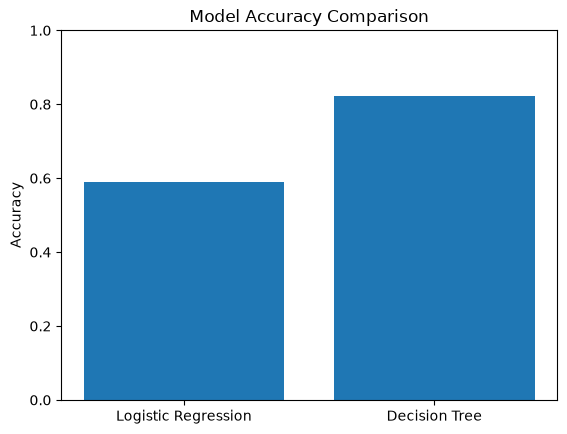

In [165]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Decision Tree"]
accuracies = [accuracy, tree_accuracy]

plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

## Conclusion

In this prediction and analysis project, I looked at flight data from January 2025 to see which factors were linked to flight delays. I looked at things like the airline, departure airport and scheduled departure time.

I found that some airlines and airports had higher delay rates than others. I also noticed that flights later in the day generally had more delays than flights in the early morning.

I then used the data to build two simple machine learning models: Logistic Regression and a Decision Tree.

The Decision Tree had a higher accuracy of about 82% compared with about 58% for Logistic Regression. However, I found that the Decision Tree was barely detecting any of the flights that were actually delayed. This showed me that just looking at accuracy can be misleading.

The Logistic Regression model was better at finding actual delayed flights but it wasn't a very accurate model overall.

The main thing I learned from this project was how to take a real dataset, clean it, find patterns/trends in it and then use and train a machine learning model to make predictions. I also learned in depth about different python modules and their uses, for example, using matplotlib for creating graphs to make summarised data and comparisions more understandable.
